In [1]:
import requests
import pandas as pd

url_prefix = 'https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/main/cohorts/2025/03-evaluation/'

docs_url = url_prefix + 'search_evaluation/documents-with-ids.json'
documents = requests.get(docs_url).json()

ground_truth_url = url_prefix + 'search_evaluation/ground-truth-data.csv'
df_ground_truth = pd.read_csv(ground_truth_url)
df_ground_truth = df_ground_truth[df_ground_truth.course == 'machine-learning-zoomcamp']
ground_truth = df_ground_truth.to_dict(orient='records')

In [11]:
documents[0]

{'text': "The purpose of this document is to capture frequently asked technical questions\nThe exact day and hour of the course will be 15th Jan 2024 at 17h00. The course will start with the first  “Office Hours'' live.1\nSubscribe to course public Google Calendar (it works from Desktop only).\nRegister before the course starts using this link.\nJoin the course Telegram channel with announcements.\nDon’t forget to register in DataTalks.Club's Slack and join the channel.",
 'section': 'General course-related questions',
 'question': 'Course - When will the course start?',
 'course': 'data-engineering-zoomcamp',
 'id': 'c02e79ef'}

In [3]:
ground_truth[10]

{'question': 'Are sessions recorded if I miss one?',
 'course': 'machine-learning-zoomcamp',
 'document': '5170565b'}

In [16]:
doc_idx = {d['id']: d for d in documents}
doc_idx['5170565b']['text']


'Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.'

In [17]:
from sentence_transformers import SentenceTransformer

model_name = 'multi-qa-MiniLM-L6-cos-v1'
model = SentenceTransformer(model_name)

/workspaces/llm-zoomcamp/.venv310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████████████████████████████████| 103/103 [00:02<00:00, 49.85it/s]


In [18]:
from tqdm.auto import tqdm

vectors = [] 

for doc in tqdm(documents):
    question = doc['question']
    text = doc['text']
    vector= model.encode(question + ' ' + text)
    vectors.append(vector)

100%|███████████████████████████████████████████████████████| 948/948 [00:58<00:00, 16.31it/s]


In [19]:
import numpy as np

vectors = np.array(vectors)

In [20]:
from minsearch import VectorSearch

vindex = VectorSearch(keyword_fields=['course'])
vindex.fit(vectors, documents)
                      

In [21]:
def minsearch_vector_search(vector, course):
    return vindex.search(
        vector,
        filter_dict={'course': course},
        num_results=5
    )

def question_text_vector(q):
    question = q['question']
    course = q['course']
    print(course, question)

    v_q = model.encode(question)

    return minsearch_vector_search(v_q, course)    

In [23]:
question_text_vector(dict(
    question='Are sessions recorded if I miss one?',
    course = 'machine-learning-zoomcamp'
))

machine-learning-zoomcamp Are sessions recorded if I miss one?


[{'text': 'Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.',
  'section': 'General course-related questions',
  'question': 'What if I miss a session?',
  'course': 'machine-learning-zoomcamp',
  'id': '5170565b'},
 {'text': 'The course videos are pre-recorded, you can start watching the course right now.\nWe will also occasionally have office hours - live sessions where we will answer your questions. The office hours sessions are recorded too.\nYou can see the office hours as well as the pre-recorded course videos in the course playlist on YouTube.',
  'section': 'General course-related questions',
  'question': 'Is it going to be live? When?',
  'course': 'machine-learning-zoomcamp',
  'id': '39fda9f0'},
 {'text': "Problem description\nThe accuracy and the loss are both still the same or nearly the same while training.\nSol

In [22]:
def build_prompt(query, search_results):
    prompt_template = """
You're a course teaching assistant. Answer the QUESTION based on the CONTEXT from the FAQ database.
Use only the facts from the CONTEXT when answering the QUESTION.

QUESTION: {question}

CONTEXT: 
{context}
""".strip()

    context = ""
    
    for doc in search_results:
        context = context + f"section: {doc['section']}\nquestion: {doc['question']}\nanswer: {doc['text']}\n\n"
    
    prompt = prompt_template.format(question=query, context=context).strip()
    return prompt

In [16]:
from openai import OpenAI
import os
api_key = os.getenv("OPENROUTER_API_KEY")
api_key

client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=api_key,
)

In [17]:
def llm(prompt, model='openrouter/free'):
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}]
    )
    
    return response.choices[0].message.content

In [25]:
def rag(query:dict, model='openrouter/free') -> str:
    search_results = question_text_vector(query)
    prompt = build_prompt(query['question'], search_results)
    answer = llm(prompt, model=model)
    return answer

In [28]:
ground_truth[10]

{'question': 'Are sessions recorded if I miss one?',
 'course': 'machine-learning-zoomcamp',
 'document': '5170565b'}

In [29]:
rag({'question': 'Are sessions recorded if I miss one?',  'course': 'machine-learning-zoomcamp'})

machine-learning-zoomcamp Are sessions recorded if I miss one?


'Based solely on the CONTEXT:\n\nYes, sessions are recorded if you miss one. Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.'

In [31]:
doc_idx['5170565b']['text']

'Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.'

In [6]:
answer_orig = 'Yes, sessions are recorded if you miss one. Everything is recorded, allowing you to catch up on any missed content. Additionally, you can ask questions in advance for office hours and have them addressed during the live stream. You can also ask questions in Slack.'
answer_llm = 'Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.'

v_llm = model.encode(answer_llm)
v_orig = model.encode(answer_orig)

v_llm.dot(v_orig)

np.float32(0.759117)

In [7]:
ground_truth[0]

{'question': 'Where can I sign up for the course?',
 'course': 'machine-learning-zoomcamp',
 'document': '0227b872'}

In [ ]:
answers = {}

for i, rec in enumerate(tqdm(ground_truth)):
    if i in answers:
        continue

    answer_llm = rag(rec)
    doc_id = rec['document']
    original_doc = doc_idx[doc_id]
    answer_orig = original_doc['text']

    answers[i] = {
        'answer_llm': answer_llm,
        'answer_orig': answer_orig,
        'document': doc_id,
        'question': rec['question'],
        'course': rec['course'],
    }

In [ ]:
results_gpt4o = [None] * len(ground_truth)

for i, val in answers.items():
    results_gpt4o[i] = val.copy()
    results_gpt4o[i].update(ground_truth[i])

In [ ]:
import pandas as pd

In [ ]:
df_gpt4o = pd.DataFrame(results_gpt4o)

In [ ]:
!mkdir data

In [ ]:
df_gpt4o.to_csv('data/results-gpt4o.csv', index=False)

In [1]:
## Cosine Similarity

In [4]:
import requests
import pandas as pd

url_prefix = 'https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/main/cohorts/2025/03-evaluation/'

ground_truth_url = url_prefix + 'rag_evaluation/data/results-gpt4o.csv'
df_gpt4o = pd.read_csv(ground_truth_url)

results_gpt4o = df_gpt4o.to_dict(orient='records')

In [6]:
results_gpt4o[0]

{'answer_llm': 'The CONTEXT provided does not give specific instructions on how to sign up for the course. However, it does mention that you can access the course materials on the course page: [ML Zoomcamp](http://mlzoomcamp.com/). \n\nYou might want to start by visiting the course website and looking for further instructions there, as it likely has additional details on how to sign up or enroll in the course.',
 'answer_orig': 'Machine Learning Zoomcamp FAQ\nThe purpose of this document is to capture frequently asked technical questions.\nWe did this for our data engineering course and it worked quite well. Check this document for inspiration on how to structure your questions and answers:\nData Engineering Zoomcamp FAQ\nIn the course GitHub repository there’s a link. Here it is: https://airtable.com/shryxwLd0COOEaqXo\nwork',
 'document': '0227b872',
 'question': 'Where can I sign up for the course?',
 'course': 'machine-learning-zoomcamp'}

In [7]:
def compute_similarity(record):
    answer_orig = record['answer_orig']
    answer_llm = record['answer_llm']

    v_llm = model.encode(answer_llm)
    v_orig = model.encode(answer_orig)

    return v_llm.dot(v_orig)
    

In [26]:
similarity = []

for record in tqdm(results_gpt4o):
    sim = compute_similarity(record)
    similarity.append(sim)

100%|█████████████████████████████████████████████████████| 1830/1830 [02:59<00:00, 10.18it/s]


In [27]:
df_gpt4o['cosine'] = similarity
df_gpt4o['cosine'].describe()

count    1830.000000
mean        0.679129
std         0.217995
min        -0.153426
25%         0.591460
50%         0.734788
75%         0.835390
max         0.995338
Name: cosine, dtype: float64

In [33]:
import seaborn as sns

In [30]:
## gpt-3.5-turbo

In [5]:
ground_truth_url = url_prefix + 'rag_evaluation/data/results-gpt35.csv'
df_gpt35 = pd.read_csv(ground_truth_url)

results_gpt35 = df_gpt35.to_dict(orient='records')

In [39]:
similarity_35 = []

for record in tqdm(results_gpt35):
    sim = compute_similarity(record)
    similarity_35.append(sim)

100%|█████████████████████████████████████████████████████| 1830/1830 [02:21<00:00, 12.98it/s]


In [40]:
df_gpt35['cosine'] = similarity_35
df_gpt35['cosine'].describe()

count    1830.000000
mean        0.657599
std         0.226062
min        -0.168921
25%         0.546504
50%         0.714783
75%         0.817262
max         1.000000
Name: cosine, dtype: float64

In [41]:
import matplotlib.pyplot as plt

/tmp/ipykernel_3995/2146648836.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_gpt35['cosine'], label='3.5')


KeyError: 'cosine'

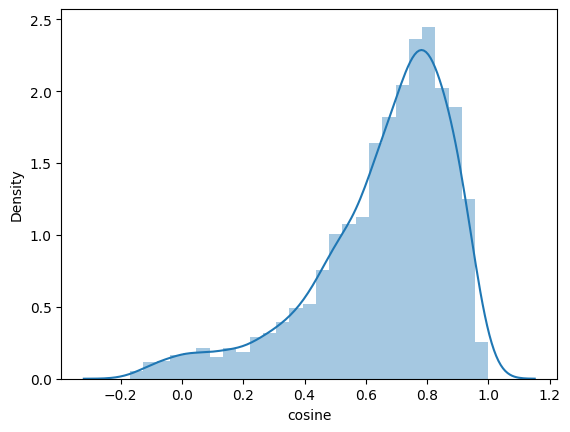

In [42]:
sns.distplot(df_gpt35['cosine'], label='3.5')
sns.distplot(df_gpt4o['cosine'], label='4o')
# sns.distplot(df_gpt4o_mini['cosine'], label='4o-mini')

plt.title("RAG LLM performance")
plt.xlabel("A->Q->A' Cosine Similarity")
plt.legend()

In [2]:
### LLM as a judge

In [3]:
prompt1_template = """
You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system.
Your task is to analyze the relevance of the generated answer compared to the original answer provided.
Based on the relevance and similarity of the generated answer to the original answer, you will classify
it as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Original Answer: {answer_orig}
Generated Question: {question}
Generated Answer: {answer_llm}

Please analyze the content and context of the generated answer in relation to the original
answer and provide your evaluation in parsable JSON without using code blocks:

{{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "Explanation": "[Provide a brief explanation for your evaluation]"
}}
""".strip()

prompt2_template = """
You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system.
Your task is to analyze the relevance of the generated answer to the given question.
Based on the relevance of the generated answer, you will classify it
as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Question: {question}
Generated Answer: {answer_llm}

Please analyze the content and context of the generated answer in relation to the question
and provide your evaluation in parsable JSON without using code blocks:

{{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "Explanation": "[Provide a brief explanation for your evaluation]"
}}
""".strip()

In [7]:
df_sample = df_gpt4o.sample(n=150, random_state=1)

In [9]:
df_sample

,answer_llm,answer_orig,document,question,course
726,The syntax for using `precision_recall_fscore_...,Scikit-learn offers another way: precision_rec...,403bbdd8,What is the syntax for using precision_recall_...,machine-learning-zoomcamp
1662,"To avoid pickle errors when using waitress, yo...",When running a docker container with waitress ...,236864c2,How should I modify my scripts to avoid pickle...,machine-learning-zoomcamp
834,To launch a container image in interactive mod...,Launch the container image in interactive mode...,63a81b57,What command launches a container image in int...,machine-learning-zoomcamp
1234,"Yes, you can make a pull request for homework ...",Pytorch is also a deep learning framework that...,c4ff26e5,Can we make a pull request for homework soluti...,machine-learning-zoomcamp
1323,The pip version error in this week's serverles...,When running docker build -t dino-dragon-model...,42c09143,What might be the cause of the pip version err...,machine-learning-zoomcamp
...,...,...,...,...,...
161,If GitHub no longer supports password authenti...,I had a problem when I tried to push my code f...,7b907071,What should I do if password authentication fo...,machine-learning-zoomcamp
60,You can find instructions to install TensorFlo...,Here is an article that worked for me: https:/...,34b7fd35,Where can I find instructions to install Tenso...,machine-learning-zoomcamp
655,In the context of calculating the AUC score us...,When calculating the ROC AUC score using sklea...,7d40f6f6,What is the role of y_true in calculating the ...,machine-learning-zoomcamp
1386,To solve the issue of Jupyter notebook not rec...,On vscode running jupyter notebook. After I ‘p...,ea2e7458,How did Quinn Avila solve the issue of Jupyter...,machine-learning-zoomcamp


In [10]:
samples = df_sample.to_dict(orient='records')

In [11]:
record = samples[0]
record

{'answer_llm': 'The syntax for using `precision_recall_fscore_support` in Python is as follows:\n\n```python\nfrom sklearn.metrics import precision_recall_fscore_support\n\nprecision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)\n```\n\nHere, `y_val` represents the true labels, `y_val_pred` represents the predicted labels, and `zero_division=0` specifies how to handle divisions by zero. This will return the precision, recall, F1 score, and support for each class.',
 'answer_orig': 'Scikit-learn offers another way: precision_recall_fscore_support\nExample:\nfrom sklearn.metrics import precision_recall_fscore_support\nprecision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)\n(Gopakumar Gopinathan)',
 'document': '403bbdd8',
 'question': 'What is the syntax for using precision_recall_fscore_support in Python?',
 'course': 'machine-learning-zoomcamp'}

In [13]:
prompt = prompt1_template.format(**record)
print(prompt)

You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system.
Your task is to analyze the relevance of the generated answer compared to the original answer provided.
Based on the relevance and similarity of the generated answer to the original answer, you will classify
it as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Original Answer: Scikit-learn offers another way: precision_recall_fscore_support
Example:
from sklearn.metrics import precision_recall_fscore_support
precision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val_pred, zero_division=0)
(Gopakumar Gopinathan)
Generated Question: What is the syntax for using precision_recall_fscore_support in Python?
Generated Answer: The syntax for using `precision_recall_fscore_support` in Python is as follows:

```python
from sklearn.metrics import precision_recall_fscore_support

precision, recall, fscore, support = precision_recall_fscore_support(y_val, y_val

In [18]:
answer = llm(prompt, model='gpt-4o-mini')

In [19]:
answer

'{\n  "Relevance": "RELEVANT",\n  "Explanation": "The generated answer closely follows the original answer by providing both the syntax for using `precision_recall_fscore_support` and an explanation of its parameters. It directly addresses the question about the syntax, matching the content and context of the original answer."\n}'

In [21]:
import json
from tqdm.auto import tqdm

evaluations = []

for record in tqdm(samples):
    prompt = prompt1_template.format(**record)
    evaluation = llm(prompt, model='gpt-4o-mini')
    evaluations.append(evaluation)

/workspaces/llm-zoomcamp/.venv310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [04:03<00:00,  1.62s/it]


In [23]:
json_evaluations = []

for i, str_eval in enumerate(evaluations):
    json_eval = json.loads(str_eval)
    json_evaluations.append(json_eval)

In [24]:
json_evaluations[0]

{'Relevance': 'RELEVANT',
 'Explanation': 'The generated answer provides a clear and correct syntax for using the `precision_recall_fscore_support` function in Python, which directly corresponds to the information in the original answer. It includes the necessary code and explanations of parameters, maintaining the context and details from the original response.'}

In [25]:
df_evaluations = pd.DataFrame(json_evaluations)

In [27]:
df_evaluations.Relevance.value_counts()

Relevance
RELEVANT           126
PARTLY_RELEVANT     17
NON_RELEVANT         7
Name: count, dtype: int64

In [28]:
prompt = prompt2_template.format(**record)
print(prompt)

You are an expert evaluator for a Retrieval-Augmented Generation (RAG) system.
Your task is to analyze the relevance of the generated answer to the given question.
Based on the relevance of the generated answer, you will classify it
as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Question: What modification was made to the median_house_value target in the homework?
Generated Answer: In the homework, the modification made to the median_house_value target was twofold:
1. For calculating the mutual information score, the median_house_value (which is a continuous variable) was converted into a binary format. This means its values were made discrete as either 0 or 1.
2. Additionally, a log transformation was applied to the median_house_value variable to improve RMSE for regression tasks, as instructed before Question 3 in the Week-2 homework.

Please remember these transformations when working on relevant questions.

Please analyze the content and con

In [29]:
evaluation = llm(prompt, model='gpt-4o-mini')
print(evaluation)

{
  "Relevance": "RELEVANT",
  "Explanation": "The generated answer directly addresses the modification made to the median_house_value target in the homework by detailing the two transformations: converting it to a binary format and applying a log transformation. Both of these points are specifically related to the question asked, thus making the answer relevant."
}


In [30]:
evaluations_2 = []

for record in tqdm(samples):
    prompt = prompt2_template.format(**record)
    evaluation = llm(prompt, model='gpt-4o-mini')
    evaluations_2.append(evaluation)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [03:49<00:00,  1.53s/it]


In [31]:
json_evaluations_2 = []

for i, str_eval in enumerate(evaluations_2):
    json_eval = json.loads(str_eval)
    json_evaluations_2.append(json_eval)

In [32]:
df_evaluations_2 = pd.DataFrame(json_evaluations_2)

In [33]:
df_evaluations_2[df_evaluations_2.Relevance == 'NON_RELEVANT']

,Relevance,Explanation
49,NON_RELEVANT,The generated answer does not address the ques...
102,NON_RELEVANT,The generated answer suggests importing the 'p...
139,NON_RELEVANT,The generated answer does not address the ques...


In [35]:
samples[45]

{'answer_llm': "The provided CONTEXT does not specifically mention the commands to start the Docker daemon on Linux. For detailed instructions, it's best to refer to the official Docker documentation for your specific Linux distribution. Generally, you can start the Docker daemon on most Linux distributions using the following command:\n\n```sh\nsudo systemctl start docker\n```\n\nTo enable Docker to start at boot, you can use:\n\n```sh\nsudo systemctl enable docker\n```\n\nAgain, please refer to the Docker documentation for distribution-specific instructions.",
 'answer_orig': 'Working on getting Docker installed - when I try running hello-world I am getting the error.\nDocker: Cannot connect to the docker daemon at unix:///var/run/docker.sock. Is the Docker daemon running ?\nSolution description\nIf you’re getting this error on WSL, re-install your docker: remove the docker installation from WSL and install Docker Desktop on your host machine (Windows).\nOn Linux, start the docker da